# 02 · Performance Forecasting — Gradient Boosting

**Goal** — forecast an employee's upcoming **performance score** (continuous 40–100) from
historical KPI completion (`kpi_achievement_percent`, `performance_last_year`,
`performance_two_years_ago`), attendance consistency (`attendance_rate`, `late_days`,
`avg_monthly_hours`) and training participation (`training_hours_last_year`,
`certifications_count`, `skill_assessment_score`). This gives HR an early read on likely
high/low performers, complementing the manual weighted-KPI scoring in the Performance module.

**Algorithm — Gradient Boosting** (`HistGradientBoostingRegressor`, scikit-learn's
histogram-based gradient boosting — the scalable variant for this ~100k-row table). Chosen
for its accuracy on tabular data with non-linear feature interactions. Rationale + citations
in `../MODEL-JUSTIFICATION.md`.

As confirmed, the performance model is built on the **promotion dataset**
(`employee_promotion_prediction.csv`) — its `performance_score` column is the richest
performance signal across the datasets. Logged to `logs/performance*.log`; artifacts under
`artifacts/performance/`.

> **Leakage note:** the `promoted` outcome is dropped (downstream of performance);
> historical performance columns are kept as legitimate predictors.

In [1]:
# --- environment & logged run -------------------------------------------------------
import sys
from pathlib import Path

# notebooks/ live one level below the model root where synapse_ml.py sits
HERE = Path.cwd()
MODEL_DIR = HERE if (HERE / "synapse_ml.py").exists() else HERE.parent
sys.path.insert(0, str(MODEL_DIR))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)

import synapse_ml as sm
run = sm.start_run("performance")   # opens logs/performance_<ts>.log + artifacts/performance/
log = run.log

INFO    | ==============================================================================


INFO    | RUN START · model=performance · 2026-06-23T03:18:59


INFO    | python=3.14.4 · platform=Windows-11-10.0.26200-SP0


INFO    | log file=C:\Users\Earl Kian\Documents\Project\synapse\model\logs\performance_20260623_031859.log


INFO    | artifacts=C:\Users\Earl Kian\Documents\Project\synapse\model\artifacts\performance


INFO    | libs · numpy=2.5.0, pandas=2.3.3, scipy=1.18.0, sklearn=1.9.0, matplotlib=3.11.0, seaborn=0.13.2


## 1 · Load data

In [2]:
df = run.load_csv("employee_promotion_prediction.csv")
print(df.shape)
df.head()

INFO    | loading data · C:\Users\Earl Kian\Documents\Project\synapse\model\employee_promotion_prediction.csv


INFO    | loaded shape=(100000, 43) · columns=43


(100000, 43)


,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,years_since_last_promotion,team_size,performance_score,performance_last_year,performance_two_years_ago,manager_rating,peer_feedback_score,projects_completed,kpi_achievement_percent,innovation_score,leadership_score,problem_solving_score,avg_monthly_hours,overtime_hours,tasks_completed,deadline_adherence_rate,meeting_hours_per_month,remote_work_ratio,training_hours_last_year,certifications_count,skill_assessment_score,cross_department_projects,mentoring_sessions,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,4,10,7,100.000000,100.000000,85.964051,4.026107,3.931381,4,90.518924,70.395227,83.068321,46.634645,150.935199,20.217535,24.308108,0.861171,24.534005,0.354708,25.361303,2,67.560751,1,3,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,5,3,8,72.008233,78.270415,70.963042,4.135957,3.497259,9,58.125175,74.505077,76.840144,52.749119,177.389542,28.581193,59.627936,0.806096,29.574865,0.065833,43.760654,4,74.851443,6,2,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,5,6,6,77.244045,72.824611,59.960718,3.477986,3.235364,7,79.305915,51.705306,62.997452,58.887897,166.931246,17.438137,43.804607,0.702354,29.934692,0.073399,25.275693,2,44.964704,1,4,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,4,2,12,49.061426,54.280668,40.000000,2.353257,1.966977,4,39.937656,50.977286,61.068605,54.714039,136.047654,14.855971,30.485655,0.871308,27.529029,0.129415,33.507680,1,50.993617,2,2,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,2,2,18,89.021698,86.075898,84.834851,4.877006,4.782039,6,78.409429,90.959425,68.382130,45.383453,198.543687,35.706433,40.948985,0.762983,18.535778,0.541355,44.730269,7,78.227838,3,2,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0


In [3]:
import io
_info = io.StringIO()
df.info(buf=_info)
log.info("dataframe info:\n%s", _info.getvalue())
df.describe().T

INFO    | dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   employee_id                 100000 non-null  int64  
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   education_level             100000 non-null  object 
 4   marital_status              100000 non-null  object 
 5   city_tier                   100000 non-null  object 
 6   department                  100000 non-null  object 
 7   employment_type             100000 non-null  object 
 8   years_at_company            100000 non-null  int64  
 9   years_in_current_role       100000 non-null  int64  
 10  years_since_last_promotion  100000 non-null  int64  
 11  team_size                   100000 non-null  int64  
 12  performance_score           100000 non-null  fl

,count,mean,std,min,25%,50%,75%,max
employee_id,100000.0,50000.500000,28867.657797,1.000000,25000.750000,50000.500000,75000.250000,100000.000000
age,100000.0,40.558140,10.951788,22.000000,31.000000,41.000000,50.000000,59.000000
years_at_company,100000.0,5.489030,3.481758,0.000000,3.000000,5.000000,7.000000,30.000000
years_in_current_role,100000.0,2.750630,2.746004,0.000000,1.000000,2.000000,4.000000,28.000000
years_since_last_promotion,100000.0,2.749650,2.733337,0.000000,1.000000,2.000000,4.000000,29.000000
team_size,100000.0,11.014010,4.910633,3.000000,7.000000,11.000000,15.000000,19.000000
performance_score,100000.0,70.097429,14.717013,40.000000,59.499890,69.980013,80.596442,100.000000
performance_last_year,100000.0,68.166798,13.867294,40.000000,58.357646,68.033605,77.791895,100.000000
performance_two_years_ago,100000.0,65.102153,11.773939,40.000000,56.954026,65.018847,73.121749,100.000000
manager_rating,100000.0,3.302642,0.765938,1.000000,2.769433,3.302663,3.837462,5.000000


## 2 · Target distribution & drivers

INFO    | target=performance_score · mean=70.10 std=14.72 min=40.00 max=100.00


INFO    | saved figure · 01_target_distribution.png


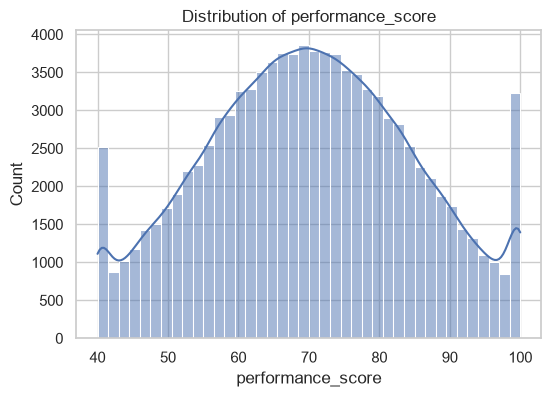

In [4]:
TARGET = "performance_score"
ID_COL = "employee_id"
DROP = [ID_COL, "promoted"]   # promoted is downstream of performance -> leakage

y = df[TARGET].astype(float)
log.info("target=%s · mean=%.2f std=%.2f min=%.2f max=%.2f",
         TARGET, y.mean(), y.std(), y.min(), y.max())

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(y, bins=40, kde=True, ax=ax, color="#4c72b0")
ax.set_title(f"Distribution of {TARGET}")
run.save_fig(fig, "01_target_distribution"); plt.show()

INFO    | numeric correlation with performance_score:
avg_monthly_hours            -0.004831
overtime_hours               -0.003476
training_hours_last_year     -0.002680
cross_department_projects    -0.002337
years_in_current_role        -0.001579
deadline_adherence_rate      -0.001532
age                          -0.000910
years_at_company             -0.000652
employee_engagement_score    -0.000170
remote_work_ratio             0.000154
team_size                     0.000355
tasks_completed               0.001157
projects_completed            0.001234
certifications_count          0.001914
years_since_last_promotion    0.002440
late_days                     0.002511
skill_assessment_score        0.002593
internal_mobility_score       0.003118
problem_solving_score         0.003428
attendance_rate               0.003885
innovation_score              0.004114
job_satisfaction_score        0.004848
mentoring_sessions            0.005068
meeting_hours_per_month       0.059532
salary    

INFO    | saved figure · 02_feature_correlation.png


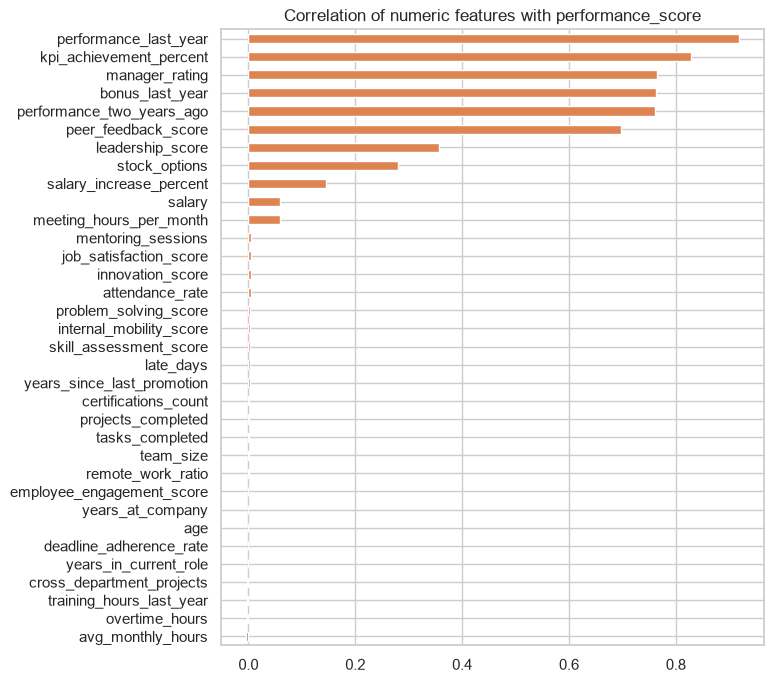

In [5]:
num_df = df.drop(columns=DROP).select_dtypes("number")
corr = num_df.corr()[TARGET].drop(TARGET).sort_values()
log.info("numeric correlation with %s:\n%s", TARGET, corr.to_string())

fig, ax = plt.subplots(figsize=(7, 8))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "#dd8452", "#4c72b0"))
ax.set_title(f"Correlation of numeric features with {TARGET}")
run.save_fig(fig, "02_feature_correlation"); plt.show()

## 3 · Preprocessing & split

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop(columns=DROP + [TARGET])
numeric_cols, categorical_cols = sm.split_feature_types(df.drop(columns=DROP), target=TARGET)
log.info("numeric=%d · categorical=%d %s", len(numeric_cols), len(categorical_cols), categorical_cols)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log.info("split · train=%s test=%s", X_train.shape, X_test.shape)

INFO    | numeric=34 · categorical=6 ['gender', 'education_level', 'marital_status', 'city_tier', 'department', 'employment_type']


INFO    | split · train=(80000, 40) test=(20000, 40)


## 4 · Gradient Boosting model

`HistGradientBoostingRegressor` — additive trees fit on the gradient of the squared-error
loss. Read by 3-fold cross-validated R² (3 folds keep the 100k-row run quick), then fit on
all training data.

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold

cv = KFold(n_splits=3, shuffle=True, random_state=42)
model = Pipeline([
    ("prep", preprocess),
    ("reg", HistGradientBoostingRegressor(
        learning_rate=0.05, max_iter=600, max_leaf_nodes=31,
        l2_regularization=1.0, early_stopping=True, random_state=42)),
])

cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
log.info("CV R2 = %.4f (+/- %.4f)", cv_r2.mean(), cv_r2.std())
model.fit(X_train, y_train)
log.info("fitted GradientBoosting on %d rows", len(X_train))

INFO    | CV R2 = 0.9180 (+/- 0.0004)


INFO    | fitted GradientBoosting on 80000 rows


## 5 · Evaluation

INFO    | test · MAE=3.331 RMSE=4.184 R2=0.9198


INFO    | saved figure · 03_pred_vs_actual_residuals.png


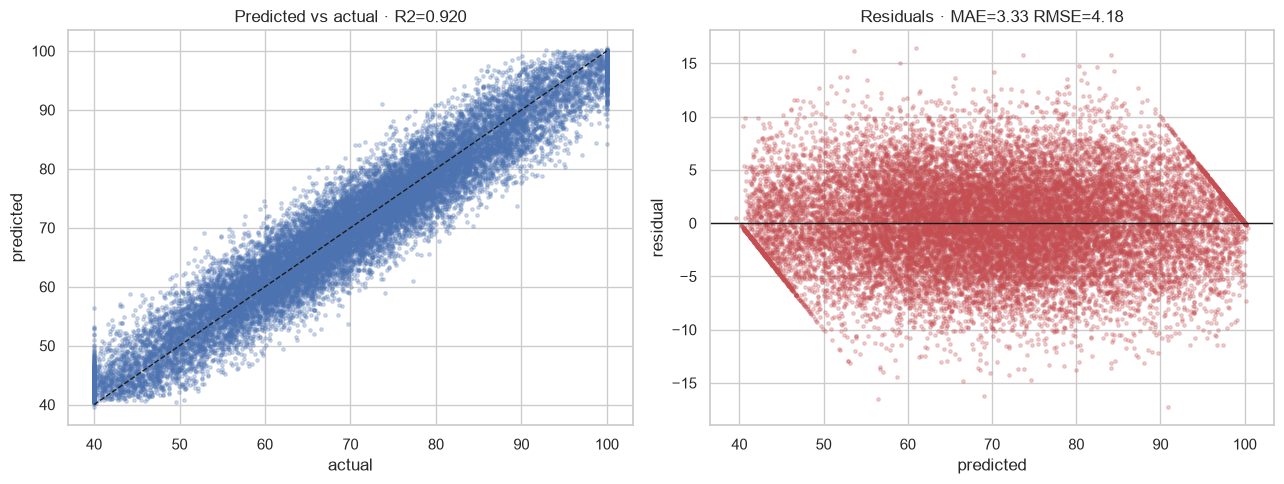

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
r2 = r2_score(y_test, pred)
log.info("test · MAE=%.3f RMSE=%.3f R2=%.4f", mae, rmse, r2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred, s=6, alpha=0.25, color="#4c72b0")
lims = [y_test.min(), y_test.max()]; axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted")
axes[0].set_title(f"Predicted vs actual · R2={r2:.3f}")
resid = y_test - pred
axes[1].scatter(pred, resid, s=6, alpha=0.25, color="#c44e52"); axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual")
axes[1].set_title(f"Residuals · MAE={mae:.2f} RMSE={rmse:.2f}")
fig.tight_layout(); run.save_fig(fig, "03_pred_vs_actual_residuals"); plt.show()

INFO    | top permutation importances:
performance_last_year        0.634758
kpi_achievement_percent      0.059549
manager_rating               0.033439
bonus_last_year              0.031704
peer_feedback_score          0.017938
leadership_score             0.003256
skill_assessment_score       0.000297
salary_increase_percent      0.000197
salary                       0.000115
tasks_completed              0.000048
innovation_score             0.000039
meeting_hours_per_month      0.000034
stock_options                0.000031
years_at_company             0.000022
performance_two_years_ago    0.000021


INFO    | saved figure · 04_permutation_importance.png


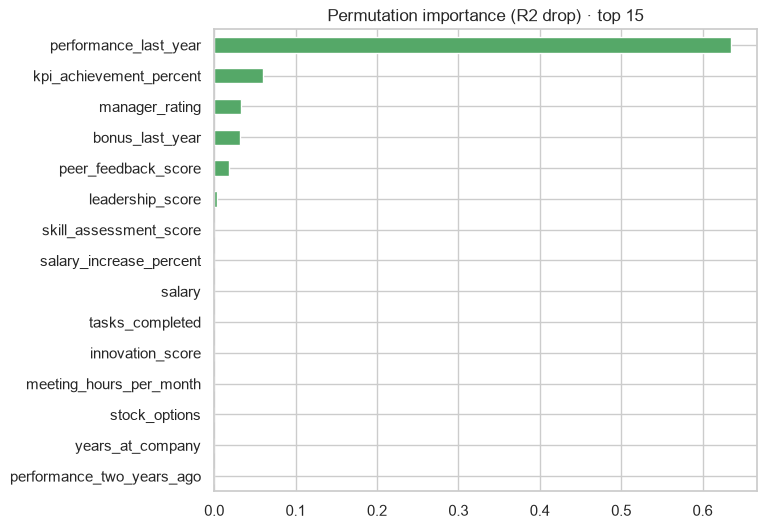

In [9]:
# Permutation importance (model-agnostic) on a test subsample.
from sklearn.inspection import permutation_importance

sample = X_test.sample(min(4000, len(X_test)), random_state=42)
perm = permutation_importance(model, sample, y_test.loc[sample.index], scoring="r2",
                              n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values().tail(15)
log.info("top permutation importances:\n%s", imp.sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
imp.plot(kind="barh", ax=ax, color="#55a868")
ax.set_title("Permutation importance (R2 drop) · top 15")
run.save_fig(fig, "04_permutation_importance"); plt.show()

## 6 · Forecast roster

Forecast scores for the test set and flag the largest gaps vs. last year's score — the
employees whose trajectory is bending up or down.

In [10]:
scored = X_test.copy()
scored["forecast_score"] = pred.round(1)
scored["actual_score"] = y_test.values.round(1)
scored["delta_vs_last_year"] = (pred - X_test["performance_last_year"]).round(1)
log.info("biggest forecast drops vs last year:\n%s",
         scored.nsmallest(5, "delta_vs_last_year")[
             ["performance_last_year", "forecast_score", "delta_vs_last_year"]].to_string())
run.checkpoint_df(scored.reset_index(names="row_id"), "forecast_roster")
scored[["performance_last_year", "forecast_score", "actual_score", "delta_vs_last_year"]].head()

INFO    | biggest forecast drops vs last year:
       performance_last_year  forecast_score  delta_vs_last_year
78230              62.006252            51.4               -10.6
20037              68.904755            58.5               -10.4
11707              66.735179            56.3               -10.4
66160              67.031127            56.8               -10.2
29056              64.195211            54.1               -10.1


WARNING | parquet unavailable (Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.); wrote CSV instead


INFO    | checkpoint dataframe · forecast_roster.csv · shape=(20000, 44)


,performance_last_year,forecast_score,actual_score,delta_vs_last_year
75721,59.350351,59.7,61.6,0.3
80184,54.966107,48.0,44.9,-6.9
19864,81.156984,86.7,84.7,5.6
76699,40.000000,43.6,40.0,3.6
92991,57.082675,56.6,56.1,-0.4


## 7 · Persist model & metrics

In [11]:
run.save_model(model, "performance_model")
run.save_metrics({
    "algorithm": "HistGradientBoostingRegressor",
    "cv_r2": float(cv_r2.mean()),
    "test_mae": mae, "test_rmse": rmse, "test_r2": r2,
    "target_mean": float(y.mean()), "target_std": float(y.std()),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
})
run.finish(summary=f"GradientBoosting: test R2={r2:.3f}, MAE={mae:.2f}, RMSE={rmse:.2f}")

INFO    | saved model · performance_model.joblib (729.2 KB)


INFO    | saved metrics · metrics.json


INFO    |   algorithm                    = HistGradientBoostingRegressor


INFO    |   cv_r2                        = 0.9180


INFO    |   test_mae                     = 3.3314


...

INFO    |   n_train                      = 80000.0000


INFO    |   n_test                       = 20000.0000


INFO    | summary · GradientBoosting: test R2=0.920, MAE=3.33, RMSE=4.18


INFO    | RUN END · model=performance · elapsed=20.8s


INFO    | ==============================================================================
